In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import sklearn

In [2]:
df = pd.read_csv("final_data.csv")
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [3]:

#caloiries -weight
#session duration - calories burned
#Experiennce - woekout fequency
bmi = df.BMI
fat_p = df.Fat_Percentage
calories = df.Calories
weight=df["Weight (kg)"]
#BMI - Weight
#BMI- fat percentage
#calories - BMI

Text(42.722222222222214, 0.5, 'BMI')

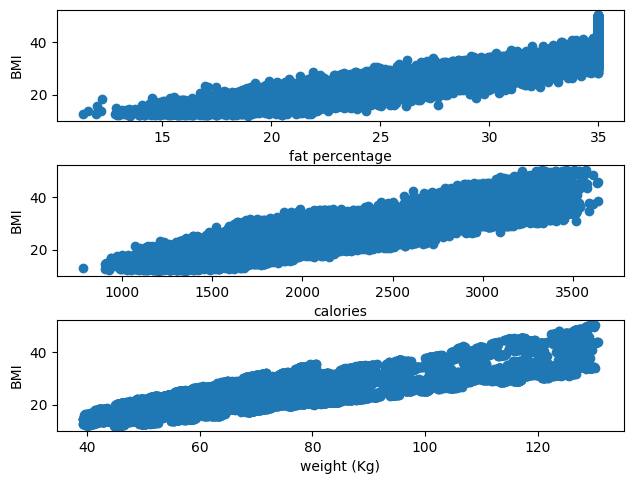

In [4]:
fig1,(ax11,ax12,ax13) = plt.subplots(3)
fig1.tight_layout()
ax11.scatter(fat_p,bmi)
ax11.set_xlabel("fat percentage")
ax11.set_ylabel("BMI")
ax12.scatter(calories,bmi)
ax12.set_xlabel("calories")
ax12.set_ylabel("BMI")
ax13.scatter(weight,bmi)
ax13.set_xlabel("weight (Kg)")
ax13.set_ylabel("BMI")

In [5]:
#my-gradient descent and scale function
def scale(x:np.ndarray,scaling:int=0):
    """
    x (ndarray) : feature values
    scaling (int) : Scaling Technique
    0 (feature scaling) : min/max < x/max < max/max
    1 (mean normalization) :  x = (x-mean)/max-min
    2 (z-score normalization) : x = (x-mean)/standard-deviation
    """

    match scaling:
        case 0:
            return x/x.max()
        case 1:
            mean=x.mean()
            return (x-mean)/(x.max()-x.min())
        case 2: 
            mean=x.mean()
            std=x.std()
            return (x-mean)/std
        case _:
            raise ValueError("Invalid input!")

def linear_regression_gradient_descent(x:np.ndarray,y:np.ndarray,w_i:float=0,b_i:float=0,alpha:float=0.001,iters:int=1000,cost:bool=False):
    """
    x (ndarray) : feature values
    y (ndarray) : target values
    w_i (float) : initial regression coefficient
    b_i (float) : initial interception value
    alpha (float) : value of learning rate
    iters (int) : number of gradient descent iterations
    cost (bool) : return cost function and number of iteration for learning curve
    """
    w=w_i
    b=b_i
    a=alpha
    m = len(x)      #total values
    cost_history=[]    #saving data for learning curve
    x_iters=np.arange(0,iters)
    for _ in range(iters):
        #Model function
        f_wb=w*x+b
        #cost function
        j_wb=(1/(2*m)) * np.sum((f_wb - y)**2)
        #derivatives
        dj_dw = (1/m) * np.sum((f_wb - y) * x)
        dj_db = (1/m) * np.sum((f_wb - y))
        cost_history.append(j_wb)
        #gradient descent
        w-= a*dj_dw
        b-= a*dj_db
    match cost:
        case False:
           return w,b
        case True:
            return w,b,cost_history,x_iters
        case _ :
            raise ValueError("Invalid input!")

In [6]:
y=bmi
x11=fat_p
x12=calories
x13 = weight
x11=scale(x11,2)
x12=scale(x12,2)
x13=scale(x13,2)
w11,b11,cost11,iters11=linear_regression_gradient_descent(x11,y,alpha=0.1,cost=True)
w12,b12=linear_regression_gradient_descent(x12,y,alpha=0.1)
w13,b13=linear_regression_gradient_descent(x13,y,alpha=0.1)

Text(0, 0.5, 'cost')

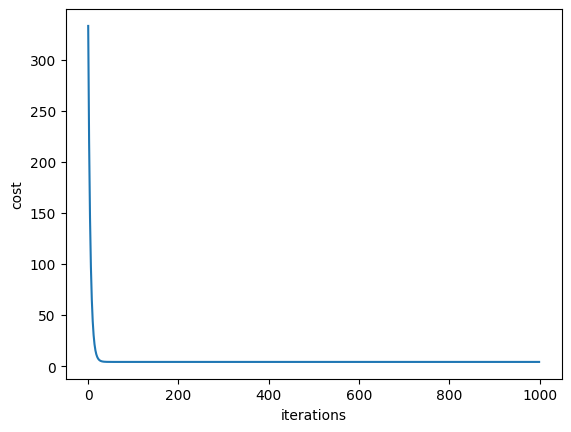

In [7]:
#ploting the cost
plt_cost1=plt.figure().add_subplot(111,)
plt_cost1.plot(iters11,cost11)
plt_cost1.set_xlabel("iterations")
plt_cost1.set_ylabel("cost")

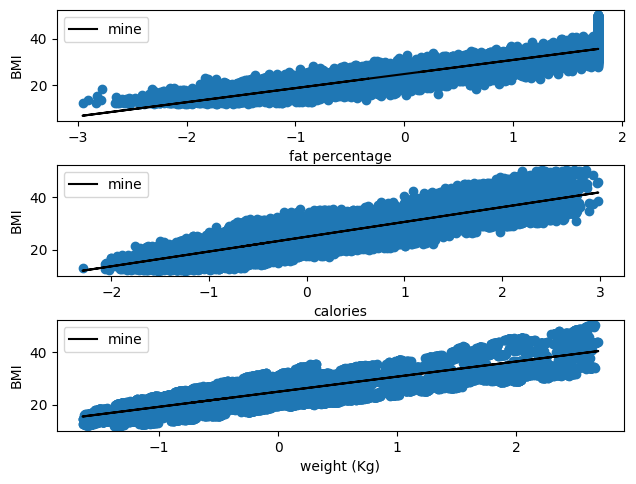

In [8]:
fig2,(ax21,ax22,ax23) = plt.subplots(3)
f11=w11*x11 + b11
f12=w12*x12 + b12
f13=w13*x13 + b13
fig2.tight_layout()
ax21.scatter(x11,y)
ax21.plot(x11,f11,label="mine",c="black")
ax21.set_xlabel("fat percentage")
ax21.set_ylabel("BMI")
ax21.legend()
ax22.scatter(x12,y)
ax22.plot(x12,f12,label="mine",c="black")
ax22.set_xlabel("calories")
ax22.set_ylabel("BMI")
ax22.legend()
ax23.scatter(x13,y)
ax23.plot(x13,f13,label="mine",c="black")
ax23.set_xlabel("weight (Kg)")
ax23.set_ylabel("BMI")
ax23.legend()

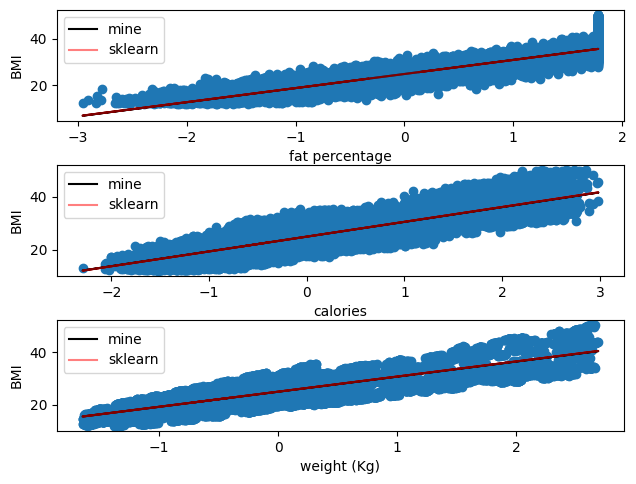

In [9]:
xs11=fat_p.to_numpy()
xs11=np.reshape(xs11,(-1,1))
xs12=calories.to_numpy()
xs12=np.reshape(xs12,(-1,1))
xs13=weight.to_numpy()
xs13=np.reshape(xs13,(-1,1))
standardizer = sklearn.preprocessing.StandardScaler()
model = sklearn.linear_model.SGDRegressor()

xs11=standardizer.fit_transform(xs11)
xs12=standardizer.fit_transform(xs12)
xs13=standardizer.fit_transform(xs13)

model.fit(xs11,y)
ax21.plot(xs11,model.predict(xs11),label="sklearn",alpha=0.5,c="red")
ax21.legend()
x1=standardizer.fit_transform(xs12)
model.fit(xs12,y)
ax22.plot(xs12,model.predict(xs12),label="sklearn",alpha=0.5,c="red")
ax22.legend()
fig2
model.fit(xs13,y)
ax23.plot(xs13,model.predict(xs13),label="sklearn",alpha=0.5,c="red")
ax23.legend()
fig2